In [ ]:
#agregando Liberías
import os
import numpy as np
from matplotlib import pyplot
from scipy import optimize
# Para poder volver los PNG's a números (a diferencia del ejemplo las imagenes de mi dataset vienen aparte así que loadmat no jala)
from PIL import Image
import pandas as pd
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#preparar los datos
!unzip -o "/content/drive/MyDrive/ia/archive.zip" -d "/content/HASYv2"
input_layer_size = 1024   # 32x32

# Número de clases
num_labels = 369

# Cargar datos
df = pd.read_csv("/content/HASYv2/hasy-data-labels.csv")

imagenes = []
for ruta in df["path"]:
    img = Image.open("/content/HASYv2/" + ruta).convert("L")
    imagenes.append(np.array(img).flatten())

X = np.array(imagenes)
y = df["symbol_id"].values.astype(float)

# Renombrar clases a 0, 1, 2, ... para que no use indices saltando en intervalos raros
clases_unicas = np.unique(y)
for i, clase in enumerate(clases_unicas):
    y[y == clase] = i

m = y.size

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95011.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95012.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95013.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95014.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95015.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95016.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95017.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95018.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95019.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95020.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95021.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95022.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95023.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95024.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95025.png  
  inflating: /content/HA

In [ ]:
print(X[0,:])
print(y)
print(X.shape)
print(y.shape)

[255 255 255 ... 255 255 255]
[  0.   0.   0. ... 368. 368. 368.]
(168233, 1024)
(168233,)


In [ ]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    """
    # Calcula filas, columnas
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promocionar a una matriz bidimensional
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensinal.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Calcula el numero de elementos a mostrar
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(32, 32),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

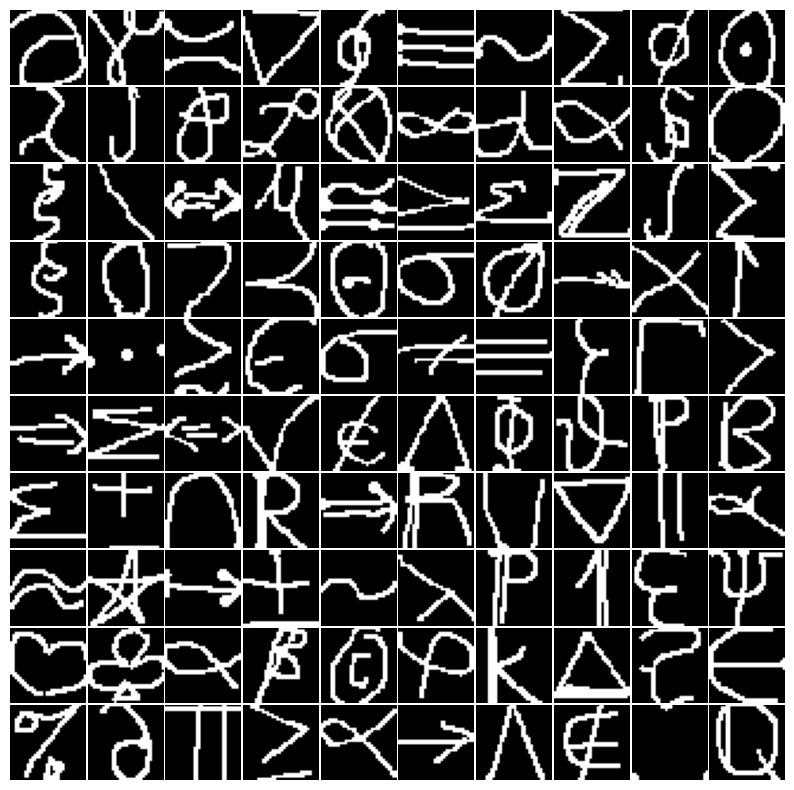

In [ ]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

In [ ]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [ ]:
def lrCostFunction(theta, X, y, lambda_):

    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # grad = (1 / m) * (h - y).dot(X)
    # grad = grad + (lambda_ / m) * temp

    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

In [ ]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)
print(X_t)
# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

[[1.  0.1 0.6 1.1]
 [1.  0.2 0.7 1.2]
 [1.  0.3 0.8 1.3]
 [1.  0.4 0.9 1.4]
 [1.  0.5 1.  1.5]]


In [ ]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('-----------------------')


Costo         : 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
-----------------------


In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
X_norm, mu, sigma = featureNormalize(X)
X = X_norm

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    """
    Trains num_labels logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta, where the i-th
    row of all_theta corresponds to the classifier for label i.

    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n). m is the number of
        data points, and n is the number of features. Note that we
        do not assume that the intercept term (or bias) is in X, however
        we provide the code below to add the bias term to X.

    y : array_like
        The data labels. A vector of shape (m, ).

    num_labels : int
        Number of possible labels.

    lambda_ : float
        The logistic regularization parameter.

    Returns
    -------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        (ie. `numlabels`) and n is number of features without the bias.
    """
    # algunas variables utiles
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    costos=[]
    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x
        costos.append(res.fun)
    return all_theta, costos

In [ ]:
lambda_ = 0.1
all_theta, costos = oneVsAll(X, y, num_labels, lambda_)

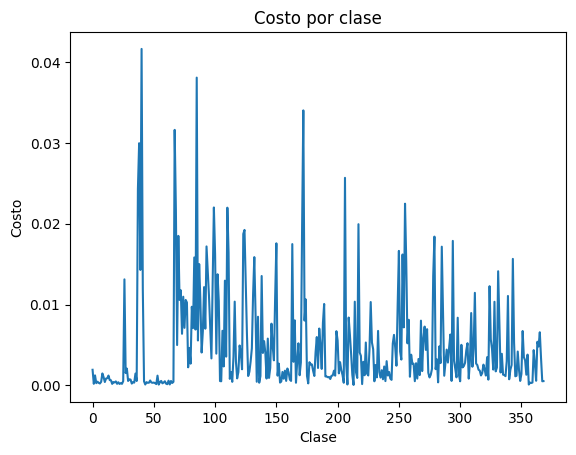

In [ ]:
pyplot.plot(costos)
pyplot.xlabel('Clase')
pyplot.ylabel('Costo')
pyplot.title('Costo por clase')
pyplot.show()

In [ ]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

In [ ]:
mapa_clases = {}
for i, clase in enumerate(clases_unicas):
    latex = df[df["symbol_id"] == clase]["latex"].values[0]
    mapa_clases[i] = latex

(168233, 1024)
Precision del conjuto de entrenamiento: 76.62%
(12, 1024)
(12, 1025)
[70 70 70 70 70 70 70 70 70 67 70 70]
\delta
\delta
\delta
\delta
\delta
\delta
\delta
\delta
\delta
\Sigma
\delta
\delta


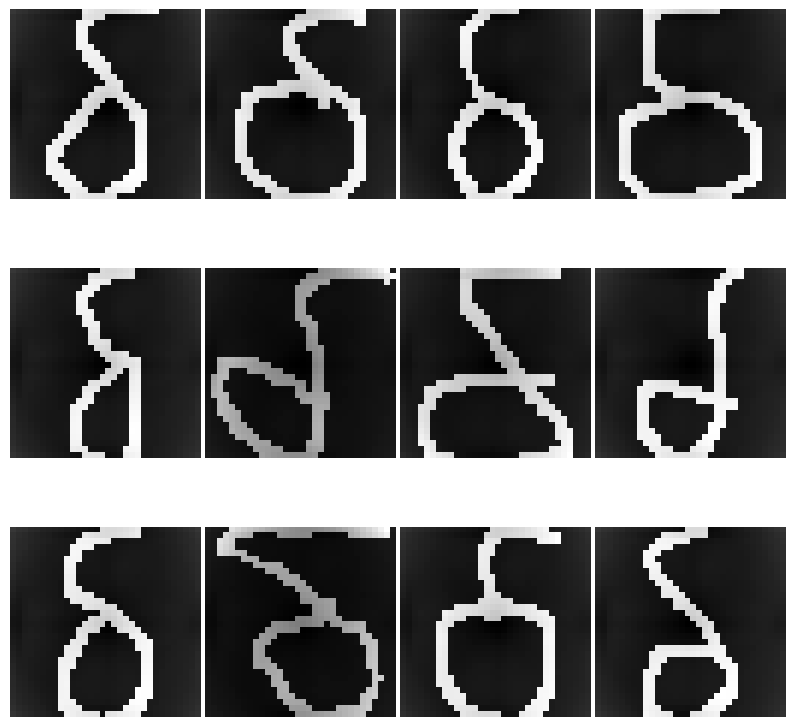

In [ ]:
print(X.shape)
pred = predictOneVsAll(all_theta, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))
XPrueba = X[2001:2013, :].copy()
print(XPrueba.shape)
XPrueba = np.concatenate([np.ones((12, 1)), XPrueba], axis=1)
print(XPrueba.shape)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis = 1)
print(p)
for c in p:
    print(mapa_clases[c])
displayData(X[2001:2013, :])

Precision: 76.62%


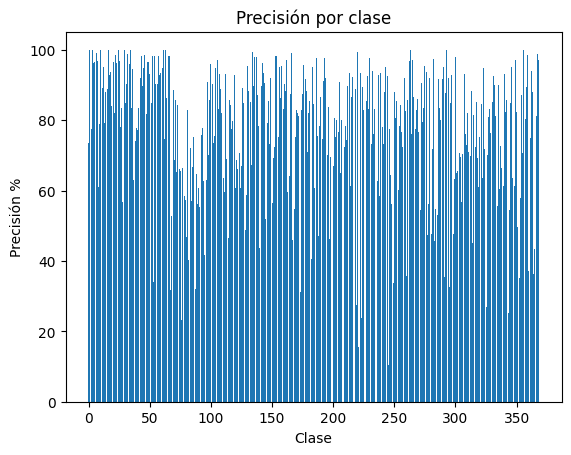

In [ ]:
pred = predictOneVsAll(all_theta, X)
print('Precision: {:.2f}%'.format(np.mean(pred == y) * 100))
precisiones = []
for c in np.arange(num_labels):
    mask = (y == c)
    precision_clase = np.mean(pred[mask] == y[mask]) * 100
    precisiones.append(precision_clase)

pyplot.bar(np.arange(num_labels), precisiones)
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión %')
pyplot.title('Precisión por clase')
pyplot.show()